# From Noise to Structure: Building a Diffusion Model from Scratch (2D Checkerboard)

This notebook walks through a **minimal diffusion model** (DDPM-style) implemented in **PyTorch** on a simple 2D toy dataset: a **checkerboard distribution**.

Why a toy dataset?
- You can *see* what diffusion is doing at each step.
- The full training loop is small enough to understand end-to-end.
- The same core mechanics scale up to image models like Stable Diffusion.

**What you’ll build**
1. A forward diffusion process that turns data into noise.
2. A tiny neural net that predicts the added noise.
3. A reverse sampling loop that turns noise back into structure.
4. Visualizations: target distribution, generated samples, and an animation of the reverse process.

Reference visuals (from the repo you linked):
- Static: https://github.com/Pdbz199/simple-diffusion-model/raw/main/diffusion_checkerboard.png  
- GIF: https://github.com/Pdbz199/simple-diffusion-model/raw/main/diffusion_process.gif


## Setup

This notebook is CPU-friendly, but training is much faster on a GPU.

Install dependencies (if needed):

```bash
pip install torch numpy matplotlib
```

Optional for saving GIF animations:
```bash
pip install imageio
```


In [1]:
# Core imports
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

# Reproducibility
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## The Math (in practice)

A diffusion model consists of:

### 1) Forward process $q$: add noise

At each timestep $t \in \{1, \dots, T\}$:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t; \sqrt{1-\beta_t} \, x_{t-1}, \beta_t I\big)$$

Define $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$.

A key Gaussian property lets us sample $x_t$ *directly* from $x_0$ without iterating:

$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

### 2) Reverse process $p_\theta$: remove noise

We learn a neural net $\epsilon_\theta(x_t, t)$ that predicts the noise $\epsilon$ added at step $t$.

### 3) Training objective (DDPM "simple" loss)

$$L = \mathbb{E}_{t, x_0, \epsilon} \Big[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \Big]$$

That's it: the model is trained to **guess the noise**.

---

### Numeric Example

Let's trace through with concrete numbers to build intuition:

**Setup:**
- Suppose $T = 100$ timesteps
- Linear $\beta$ schedule: $\beta_1 = 0.0001$, $\beta_{100} = 0.02$
- A data point $x_0 = (0.5, 0.3)$ (a point on the checkerboard)

**At $t = 50$ (midway through diffusion):**
- $\bar{\alpha}_{50} \approx 0.70$ (cumulative product of $\alpha$ values)
- $\sqrt{\bar{\alpha}_{50}} \approx 0.84$
- $\sqrt{1 - \bar{\alpha}_{50}} \approx 0.55$

**Forward sampling:**
- Sample noise $\epsilon = (0.2, -0.8)$ from $\mathcal{N}(0, I)$
- Compute $x_{50} = 0.84 \cdot (0.5, 0.3) + 0.55 \cdot (0.2, -0.8)$
- $x_{50} = (0.42, 0.25) + (0.11, -0.44) = (0.53, -0.19)$

The point has been "corrupted" — it's drifted from its original position and mixed with noise.

**At $t = 99$ (near pure noise):**
- $\bar{\alpha}_{99} \approx 0.36$
- $\sqrt{\bar{\alpha}_{99}} \approx 0.60$, $\sqrt{1 - \bar{\alpha}_{99}} \approx 0.80$
- The noise term dominates: the original signal is nearly lost!

## Data: 2D Checkerboard

We sample points uniformly in a 4×4 square, keep alternating "tiles", then normalize to roughly $[-1, 1]$ range.

This gives a crisp target manifold that's easy to visualize.

In [2]:
def generate_checkerboard_data(n_samples=50_000):
    # sample uniformly in [0,4) x [0,4)
    x1 = np.random.uniform(0, 4, n_samples)
    x2 = np.random.uniform(0, 4, n_samples)
    # keep alternating tiles
    mask = (np.floor(x1) % 2 + np.floor(x2) % 2) % 2 == 0
    data = np.vstack([x1[mask], x2[mask]]).T
    # normalize to roughly [-1, 1]
    data = (data - 2) / 2
    return torch.tensor(data, dtype=torch.float32)

x0 = generate_checkerboard_data(50_000)
x0.shape


torch.Size([24918, 2])

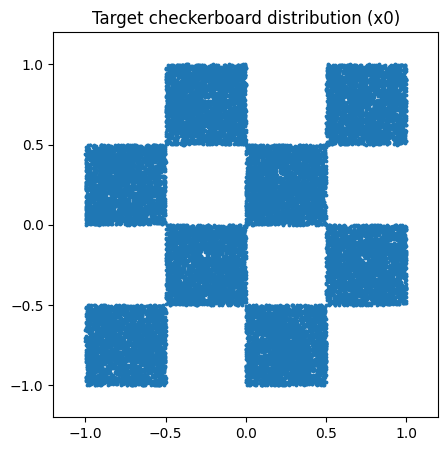

In [3]:
def plot_points(points, title="", lim=1.2, s=3):
    pts = points.detach().cpu().numpy()
    plt.figure(figsize=(5,5))
    plt.scatter(pts[:,0], pts[:,1], s=s)
    plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.show()

plot_points(x0, "Target checkerboard distribution (x0)")


## Noise schedule and precomputed coefficients

We'll use a simple linear $\beta_t$ schedule and precompute:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{s \le t} \alpha_s$

We'll store tensors on the selected device.

**Numeric insight:** With our schedule ($\beta$ from $10^{-4}$ to $0.02$):
- At $t=0$: $\bar{\alpha}_0 \approx 0.9999$ → signal is ~100% preserved
- At $t=99$: $\bar{\alpha}_{99} \approx 0.36$ → only ~60% of signal amplitude remains ($\sqrt{0.36} = 0.6$)

In [4]:
def make_beta_schedule(n_steps=100, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, n_steps)

n_steps = 100
beta = make_beta_schedule(n_steps).to(device)                 # [T]
alpha = (1.0 - beta)                                          # [T]
alpha_bar = torch.cumprod(alpha, dim=0)                       # [T]

beta[:5], beta[-5:], alpha_bar[0], alpha_bar[-1]


(tensor([1.0000e-04, 3.0101e-04, 5.0202e-04, 7.0303e-04, 9.0404e-04]),
 tensor([0.0192, 0.0194, 0.0196, 0.0198, 0.0200]),
 tensor(0.9999),
 tensor(0.3636))

## Forward diffusion: sample $x_t$ from $x_0$

Using:

$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon$$

We'll implement a helper that:
- takes a batch of $x_0$
- picks per-sample timesteps $t$
- returns $x_t$ and the true noise $\epsilon$

**Numeric Example:**

For a point $x_0 = (0.5, 0.3)$ with noise $\epsilon = (1.0, -0.5)$:

| $t$ | $\bar{\alpha}_t$ | $\sqrt{\bar{\alpha}_t}$ | $\sqrt{1-\bar{\alpha}_t}$ | $x_t$ |
|-----|------------------|-------------------------|---------------------------|-------|
| 0   | 0.9999           | 1.00                    | 0.01                      | $(0.51, 0.29)$ — almost unchanged |
| 30  | 0.85             | 0.92                    | 0.39                      | $(0.85, 0.08)$ — slight drift |
| 60  | 0.60             | 0.77                    | 0.63                      | $(1.01, -0.08)$ — significant noise |
| 99  | 0.36             | 0.60                    | 0.80                      | $(1.10, -0.22)$ — mostly noise |

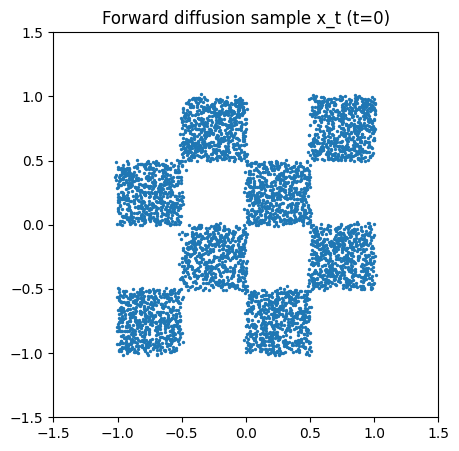

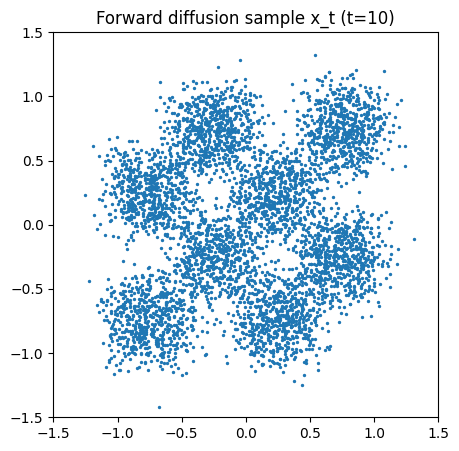

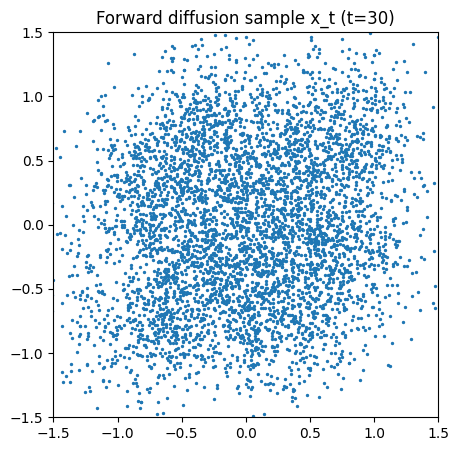

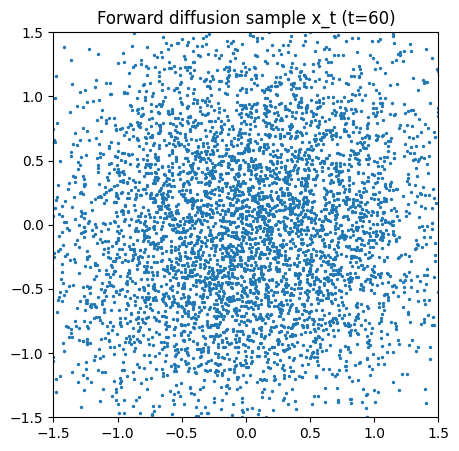

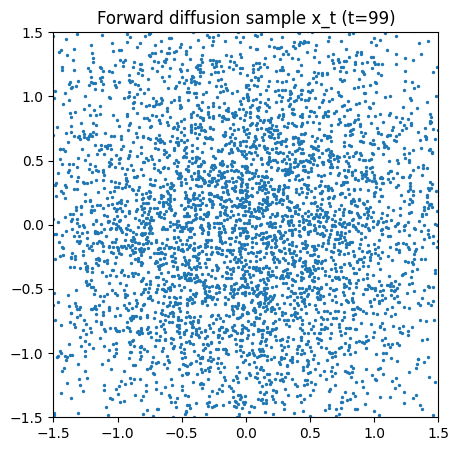

In [5]:
@torch.no_grad()
def q_sample(x0, t, alpha_bar, noise=None):
    # x0: [B,2], t: [B] (int64), alpha_bar: [T]
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = alpha_bar[t].unsqueeze(1)  # [B,1]
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise
    return xt, noise

# Visualize a few noise levels
B = 10_000
x0_batch = generate_checkerboard_data(B).to(device)
for t_val in [0, 10, 30, 60, 99]:
    t = torch.full((x0_batch.shape[0],), t_val, dtype=torch.long, device=device)
    xt, _ = q_sample(x0_batch, t, alpha_bar)
    plot_points(xt, f"Forward diffusion sample x_t (t={t_val})", lim=1.5, s=2)

## The model: a tiny MLP that predicts noise

Because our data is 2D, we don’t need a U-Net. We’ll feed:
- the noisy point \((x, y)\)
- a normalized time scalar \(t/T\)

and predict a 2D noise vector \(\hat{\epsilon}\).


In [6]:
class SimpleDiffusionModel(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x, t_norm):
        # x: [B,2], t_norm: [B,1]
        xt = torch.cat([x, t_norm], dim=1)
        return self.net(xt)

model = SimpleDiffusionModel(hidden_dim=128).to(device)
sum(p.numel() for p in model.parameters())


33794

## Training loop (DDPM simple loss)

For each mini-batch:
1. Sample timesteps $t \sim \text{Uniform}\{0, \dots, T-1\}$
2. Sample noise $\epsilon \sim \mathcal{N}(0, I)$
3. Construct $x_t$ from $x_0$
4. Predict $\hat{\epsilon} = \epsilon_\theta(x_t, t)$
5. Optimize $\text{MSE}(\hat{\epsilon}, \epsilon)$

**Why MSE works:** If the model perfectly predicts the noise that was added, we can subtract it to recover the original data. The loss directly measures how well the model "guesses" the random noise.

Tip: training longer and/or using a GPU improves sample quality.

In [7]:
def train(
    model,
    data,
    n_steps,
    alpha_bar,
    epochs=2000,
    batch_size=512,
    lr=1e-3,
    log_every=200,
):
    dataset = TensorDataset(data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    losses = []
    for ep in range(epochs):
        running = 0.0
        for (x0_batch,) in loader:
            x0_batch = x0_batch.to(device)

            t = torch.randint(0, n_steps, (x0_batch.shape[0],), device=device).long()
            eps = torch.randn_like(x0_batch)

            xt, _ = q_sample(x0_batch, t, alpha_bar, noise=eps)
            t_norm = (t.float() / (n_steps - 1)).unsqueeze(1)

            eps_pred = model(xt, t_norm)
            loss = mse(eps_pred, eps)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item()

        avg = running / len(loader)
        losses.append(avg)

        if (ep % log_every) == 0 or ep == epochs - 1:
            print(f"Epoch {ep:4d} | loss {avg:.4f}")

    return losses

# Prepare training data
train_data = generate_checkerboard_data(100_000)  # CPU tensor
losses = train(model, train_data, n_steps, alpha_bar, epochs=1500, batch_size=512, lr=1e-3, log_every=150)


Epoch    0 | loss 0.6062
Epoch  150 | loss 0.5095
Epoch  300 | loss 0.5089
Epoch  450 | loss 0.5113
Epoch  600 | loss 0.5061
Epoch  750 | loss 0.5063
Epoch  900 | loss 0.5017
Epoch 1050 | loss 0.5046
Epoch 1200 | loss 0.5091
Epoch 1350 | loss 0.5093
Epoch 1499 | loss 0.5092


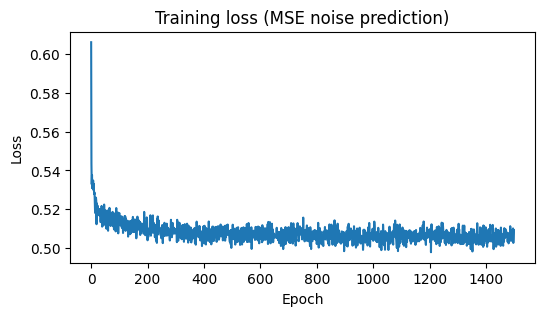

In [8]:
plt.figure(figsize=(6,3))
plt.plot(losses)
plt.title("Training loss (MSE noise prediction)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


## Reverse sampling: from noise to data

We start at $x_T \sim \mathcal{N}(0, I)$ and iteratively sample:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \, \epsilon_\theta(x_t, t) \right) + \sigma_t \, z$$

where $z \sim \mathcal{N}(0, I)$ and $\sigma_t$ is typically $\sqrt{\beta_t}$ for a simple implementation.

For a minimal demo, we'll use $\sigma_t = \sqrt{\beta_t}$ (and omit noise when $t = 0$).

---

### Numeric Example: One Reverse Step

Let's trace through step $t = 50 \to 49$:

**Given:**
- Current noisy point: $x_{50} = (0.8, -0.3)$
- Model predicts noise: $\epsilon_\theta(x_{50}, 50) = (0.5, -0.6)$
- At $t = 50$: $\alpha_{50} \approx 0.99$, $\beta_{50} \approx 0.01$, $\bar{\alpha}_{50} \approx 0.70$

**Compute the "denoised" mean:**

$$\mu = \frac{1}{\sqrt{0.99}} \left( (0.8, -0.3) - \frac{0.01}{\sqrt{1 - 0.70}} \cdot (0.5, -0.6) \right)$$

$$\mu = 1.005 \cdot \left( (0.8, -0.3) - \frac{0.01}{0.55} \cdot (0.5, -0.6) \right)$$

$$\mu = 1.005 \cdot \left( (0.8, -0.3) - (0.009, -0.011) \right)$$

$$\mu = 1.005 \cdot (0.791, -0.289) = (0.795, -0.290)$$

**Add stochasticity:**
- Sample $z = (0.1, 0.2)$
- $\sigma_{50} = \sqrt{\beta_{50}} = \sqrt{0.01} = 0.1$
- $x_{49} = (0.795, -0.290) + 0.1 \cdot (0.1, 0.2) = (0.805, -0.270)$

The point has moved slightly toward what the model thinks the clean data should look like!

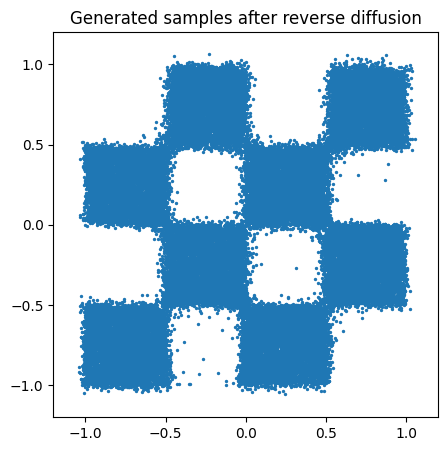

In [9]:
@torch.no_grad()
def p_sample_loop(model, n_samples, n_steps, beta, alpha, alpha_bar, return_all=False):
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    xs = [x.detach().cpu()] if return_all else None

    for t in reversed(range(n_steps)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        t_norm = (t_batch.float() / (n_steps - 1)).unsqueeze(1)

        eps_pred = model(x, t_norm)

        a_t = alpha[t]
        b_t = beta[t]
        a_bar_t = alpha_bar[t]

        # DDPM mean prediction
        mean = (1.0 / torch.sqrt(a_t)) * (x - (b_t / torch.sqrt(1.0 - a_bar_t)) * eps_pred)

        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(b_t) * noise
        else:
            x = mean

        if return_all:
            xs.append(x.detach().cpu())

    return (x.detach().cpu(), xs) if return_all else x.detach().cpu()

# Generate samples
samples = p_sample_loop(model, n_samples=50_000, n_steps=n_steps, beta=beta, alpha=alpha, alpha_bar=alpha_bar, return_all=False)
plot_points(samples, "Generated samples after reverse diffusion", lim=1.2, s=2)


## Compare real vs generated

Side-by-side scatter plots.


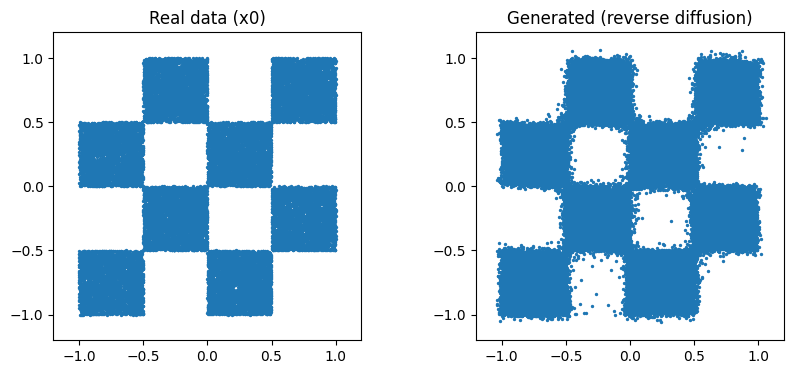

In [10]:
real = generate_checkerboard_data(50_000)
gen = samples

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
pts = real.numpy()
plt.scatter(pts[:,0], pts[:,1], s=2)
plt.title("Real data (x0)")
plt.xlim([-1.2,1.2]); plt.ylim([-1.2,1.2])
plt.gca().set_aspect('equal', adjustable='box')

plt.subplot(1,2,2)
pts = gen.numpy()
plt.scatter(pts[:,0], pts[:,1], s=2)
plt.title("Generated (reverse diffusion)")
plt.xlim([-1.2,1.2]); plt.ylim([-1.2,1.2])
plt.gca().set_aspect('equal', adjustable='box')

plt.show()


## Make a diffusion animation (optional)

This cell produces a GIF showing the whole reverse process, similar to the one in your post.

If you don’t have `imageio`, install it with:

```bash
pip install imageio
```


In [11]:
# Optional: create an animation of the reverse process
# You can skip this cell if you don't need a GIF.

try:
    import imageio.v2 as imageio
    from io import BytesIO

    final, xs = p_sample_loop(
        model, n_samples=5_000, n_steps=n_steps,
        beta=beta, alpha=alpha, alpha_bar=alpha_bar,
        return_all=True
    )

    frames = []
    for i, x in enumerate(xs[::2]):  # take every 2nd step to reduce frames
        fig = plt.figure(figsize=(4,4))
        pts = x.numpy()
        plt.scatter(pts[:,0], pts[:,1], s=3)
        plt.xlim([-1.5,1.5]); plt.ylim([-1.5,1.5])
        plt.gca().set_aspect('equal', adjustable='box')
        plt.title(f"Reverse diffusion (step {i*2})")
        buf = BytesIO()
        plt.savefig(buf, format="png", bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        frames.append(imageio.imread(buf))

    out_path = "diffusion_process.gif"
    imageio.mimsave(out_path, frames, duration=0.08)
    print(f"Saved GIF to {out_path}")

except Exception as e:
    print("Animation skipped (missing dependency or other error).")
    print("Error:", e)


Saved GIF to diffusion_process.gif


## Saving and loading checkpoints

If you want to avoid retraining every time, save the model weights:

- `torch.save(model.state_dict(), "model.pth")`
- `model.load_state_dict(torch.load("model.pth", map_location=device))`


In [12]:
# Save checkpoint
ckpt_path = "simple_diffusion_checkerboard.pth"
torch.save(model.state_dict(), ckpt_path)
ckpt_path


'simple_diffusion_checkerboard.pth'

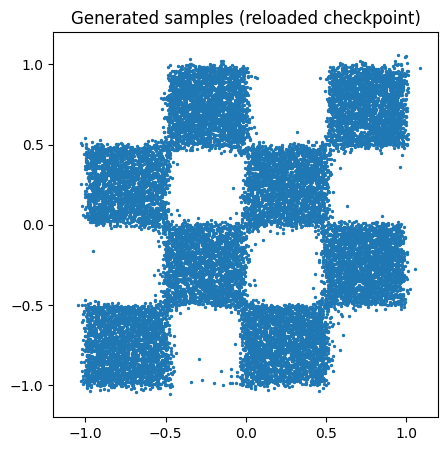

In [13]:
# Example: load checkpoint into a fresh model
model2 = SimpleDiffusionModel(hidden_dim=128).to(device)
model2.load_state_dict(torch.load(ckpt_path, map_location=device))
model2.eval()

samples2 = p_sample_loop(model2, n_samples=20_000, n_steps=n_steps, beta=beta, alpha=alpha, alpha_bar=alpha_bar)
plot_points(samples2, "Generated samples (reloaded checkpoint)", lim=1.2, s=2)


## Why this works (intuition)

The reverse process is **iterative refinement**.

At high noise levels, the model learns:  
> “Given this noisy point at timestep *t*, what noise component should be removed so the point looks *slightly* more like it came from the checkerboard?”

Because each step only needs a small correction, many small “nudges” can move samples from pure noise onto the data manifold.

This toy example contains the same core idea used in image diffusion:
- Forward process destroys information gradually
- Model learns to predict what was destroyed
- Reverse process reconstructs the structure step-by-step


## Practical Generation Examples

Now that we have a trained model, let's explore different ways to use it for generation:

1. **Basic sampling** - Generate new checkerboard points from pure noise
2. **Batch generation** - Generate many samples efficiently  
3. **Seeded generation** - Reproducible samples with fixed seeds
4. **Partial denoising** - Start from partially noisy data instead of pure noise
5. **Interpolation in noise space** - Smooth transitions between samples

In [14]:
# 1. Basic Generation: Create new samples from scratch
# This is the simplest use case - start from random noise and denoise

def generate_samples(model, n_samples, n_steps, beta, alpha, alpha_bar, seed=None):
    """Generate new samples from the trained diffusion model."""
    if seed is not None:
        torch.manual_seed(seed)
    
    model.eval()
    with torch.no_grad():
        # Start from pure Gaussian noise
        x = torch.randn(n_samples, 2, device=device)
        
        # Iteratively denoise
        for t in reversed(range(n_steps)):
            t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
            t_norm = (t_batch.float() / (n_steps - 1)).unsqueeze(1)
            
            # Predict the noise
            eps_pred = model(x, t_norm)
            
            # Compute the denoised mean
            a_t = alpha[t]
            b_t = beta[t]
            a_bar_t = alpha_bar[t]
            
            mean = (1.0 / torch.sqrt(a_t)) * (x - (b_t / torch.sqrt(1.0 - a_bar_t)) * eps_pred)
            
            # Add noise except at the final step
            if t > 0:
                x = mean + torch.sqrt(b_t) * torch.randn_like(x)
            else:
                x = mean
    
    return x.cpu()

# Generate 1000 new samples
new_samples = generate_samples(model, n_samples=1000, n_steps=n_steps, 
                                beta=beta, alpha=alpha, alpha_bar=alpha_bar, seed=42)
print(f"Generated {len(new_samples)} new samples")
print(f"Sample statistics: mean={new_samples.mean(dim=0).tolist()}, std={new_samples.std(dim=0).tolist()}")

Generated 1000 new samples
Sample statistics: mean=[-0.0028313728980720043, -0.00416695699095726], std=[0.5705289840698242, 0.5736222267150879]


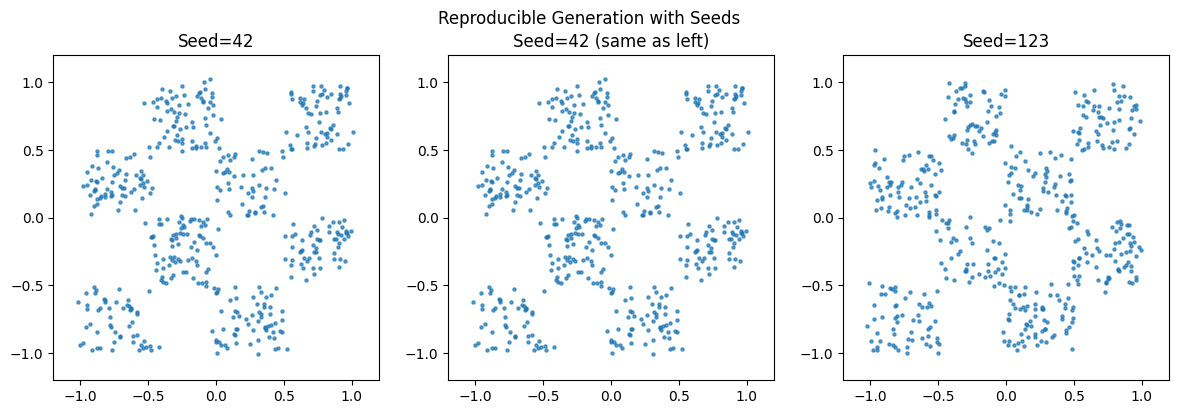

In [15]:
# 2. Seeded Generation: Reproducible results
# Using the same seed produces identical samples - useful for debugging and reproducibility

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, seed in enumerate([42, 42, 123]):
    samples = generate_samples(model, n_samples=500, n_steps=n_steps, 
                               beta=beta, alpha=alpha, alpha_bar=alpha_bar, seed=seed)
    pts = samples.numpy()
    axes[i].scatter(pts[:,0], pts[:,1], s=5, alpha=0.7)
    axes[i].set_xlim([-1.2, 1.2])
    axes[i].set_ylim([-1.2, 1.2])
    axes[i].set_aspect('equal')
    axes[i].set_title(f"Seed={seed}" + (" (same as left)" if i == 1 else ""))

plt.suptitle("Reproducible Generation with Seeds")
plt.tight_layout()
plt.show()

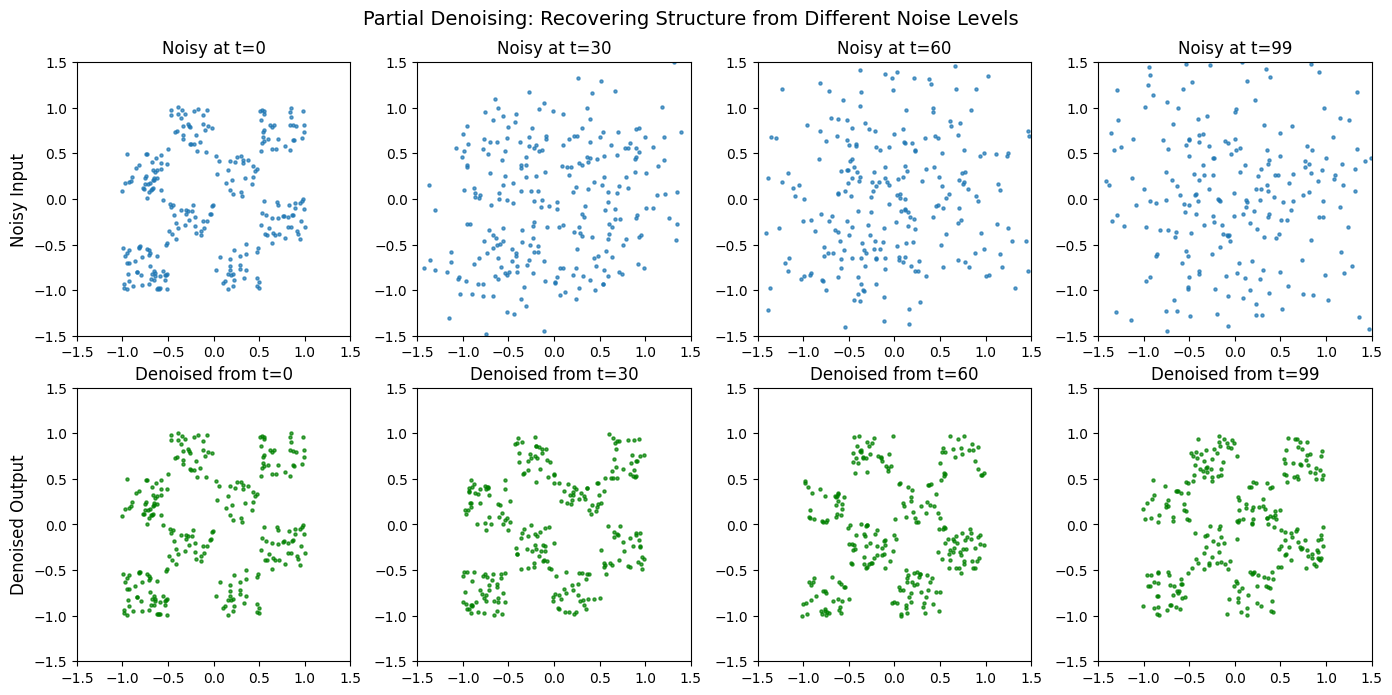

In [16]:
# 3. Partial Denoising: Start from a noisy version of real data
# Instead of pure noise, we can start from partially corrupted data
# This is the basis for image editing techniques like inpainting

@torch.no_grad()
def denoise_from_step(model, x_start, start_step, n_steps, beta, alpha, alpha_bar):
    """
    Start the reverse process from an intermediate timestep.
    x_start should already be noisy (corrupted to timestep start_step).
    """
    model.eval()
    x = x_start.to(device)
    
    for t in reversed(range(start_step + 1)):
        t_batch = torch.full((x.shape[0],), t, device=device, dtype=torch.long)
        t_norm = (t_batch.float() / (n_steps - 1)).unsqueeze(1)
        
        eps_pred = model(x, t_norm)
        
        a_t = alpha[t]
        b_t = beta[t]
        a_bar_t = alpha_bar[t]
        
        mean = (1.0 / torch.sqrt(a_t)) * (x - (b_t / torch.sqrt(1.0 - a_bar_t)) * eps_pred)
        
        if t > 0:
            x = mean + torch.sqrt(b_t) * torch.randn_like(x)
        else:
            x = mean
    
    return x.cpu()

# Take some real data points and add noise to different levels
original_points = generate_checkerboard_data(500)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Row 1: Show the noisy versions at different timesteps
noise_levels = [0, 30, 60, 99]
noisy_versions = []
for i, t_val in enumerate(noise_levels):
    t = torch.full((original_points.shape[0],), t_val, dtype=torch.long)
    xt, _ = q_sample(original_points, t, alpha_bar.cpu())
    noisy_versions.append((t_val, xt))
    
    pts = xt.numpy()
    axes[0, i].scatter(pts[:,0], pts[:,1], s=5, alpha=0.7)
    axes[0, i].set_xlim([-1.5, 1.5])
    axes[0, i].set_ylim([-1.5, 1.5])
    axes[0, i].set_aspect('equal')
    axes[0, i].set_title(f"Noisy at t={t_val}")

# Row 2: Show the denoised versions
for i, (t_val, xt) in enumerate(noisy_versions):
    if t_val == 0:
        denoised = xt  # No denoising needed
    else:
        denoised = denoise_from_step(model, xt, t_val, n_steps, beta, alpha, alpha_bar)
    
    pts = denoised.numpy()
    axes[1, i].scatter(pts[:,0], pts[:,1], s=5, alpha=0.7, c='green')
    axes[1, i].set_xlim([-1.5, 1.5])
    axes[1, i].set_ylim([-1.5, 1.5])
    axes[1, i].set_aspect('equal')
    axes[1, i].set_title(f"Denoised from t={t_val}")

axes[0, 0].set_ylabel("Noisy Input", fontsize=12)
axes[1, 0].set_ylabel("Denoised Output", fontsize=12)
plt.suptitle("Partial Denoising: Recovering Structure from Different Noise Levels", fontsize=14)
plt.tight_layout()
plt.show()

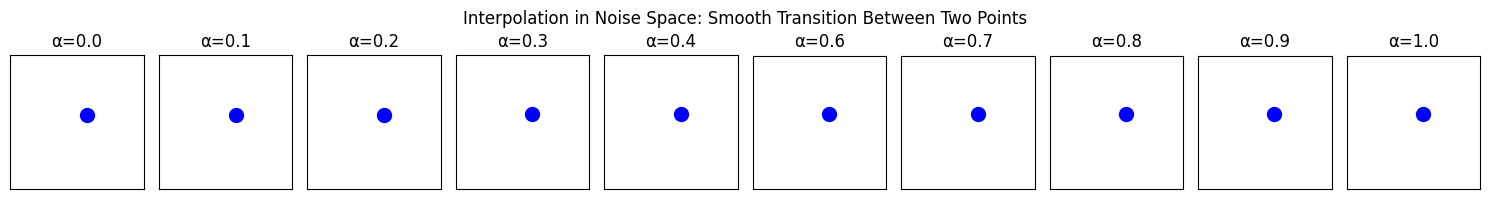

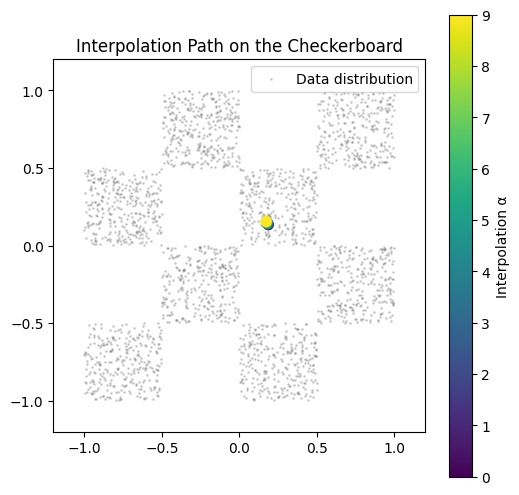

In [17]:
# 4. Interpolation in Noise Space (Latent Space)
# We can smoothly interpolate between two noise vectors and decode each
# This creates smooth transitions in the generated output

@torch.no_grad()
def generate_from_noise(model, noise, n_steps, beta, alpha, alpha_bar):
    """Generate samples starting from a specific noise vector."""
    model.eval()
    x = noise.to(device)
    
    for t in reversed(range(n_steps)):
        t_batch = torch.full((x.shape[0],), t, device=device, dtype=torch.long)
        t_norm = (t_batch.float() / (n_steps - 1)).unsqueeze(1)
        
        eps_pred = model(x, t_norm)
        
        a_t = alpha[t]
        b_t = beta[t]
        a_bar_t = alpha_bar[t]
        
        mean = (1.0 / torch.sqrt(a_t)) * (x - (b_t / torch.sqrt(1.0 - a_bar_t)) * eps_pred)
        
        if t > 0:
            # Use deterministic sampling for interpolation (no added noise)
            # This makes the mapping from noise to output deterministic
            x = mean
        else:
            x = mean
    
    return x.cpu()

# Create two random noise vectors
torch.manual_seed(42)
z1 = torch.randn(1, 2)
z2 = torch.randn(1, 2)

# Interpolate between them
n_interp = 10
alphas = torch.linspace(0, 1, n_interp)
interpolated_noise = torch.stack([
    (1 - a) * z1 + a * z2 for a in alphas
]).squeeze(1)  # [n_interp, 2]

# Generate from each interpolated noise
generated_interp = generate_from_noise(model, interpolated_noise, n_steps, beta, alpha, alpha_bar)

# Visualize
fig, axes = plt.subplots(1, n_interp, figsize=(15, 2))
for i in range(n_interp):
    axes[i].scatter([generated_interp[i, 0]], [generated_interp[i, 1]], s=100, c='blue')
    axes[i].set_xlim([-1.2, 1.2])
    axes[i].set_ylim([-1.2, 1.2])
    axes[i].set_aspect('equal')
    axes[i].set_title(f"α={alphas[i]:.1f}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle("Interpolation in Noise Space: Smooth Transition Between Two Points", fontsize=12)
plt.tight_layout()
plt.show()

# Show the trajectory on the checkerboard
plt.figure(figsize=(6, 6))
real_data = generate_checkerboard_data(5000)
plt.scatter(real_data[:,0], real_data[:,1], s=1, alpha=0.3, c='gray', label='Data distribution')
pts = generated_interp.numpy()
plt.scatter(pts[:,0], pts[:,1], s=50, c=range(n_interp), cmap='viridis', zorder=5)
plt.plot(pts[:,0], pts[:,1], 'k--', alpha=0.5, zorder=4)
plt.colorbar(label='Interpolation α')
plt.xlim([-1.2, 1.2])
plt.ylim([-1.2, 1.2])
plt.gca().set_aspect('equal')
plt.title("Interpolation Path on the Checkerboard")
plt.legend()
plt.show()

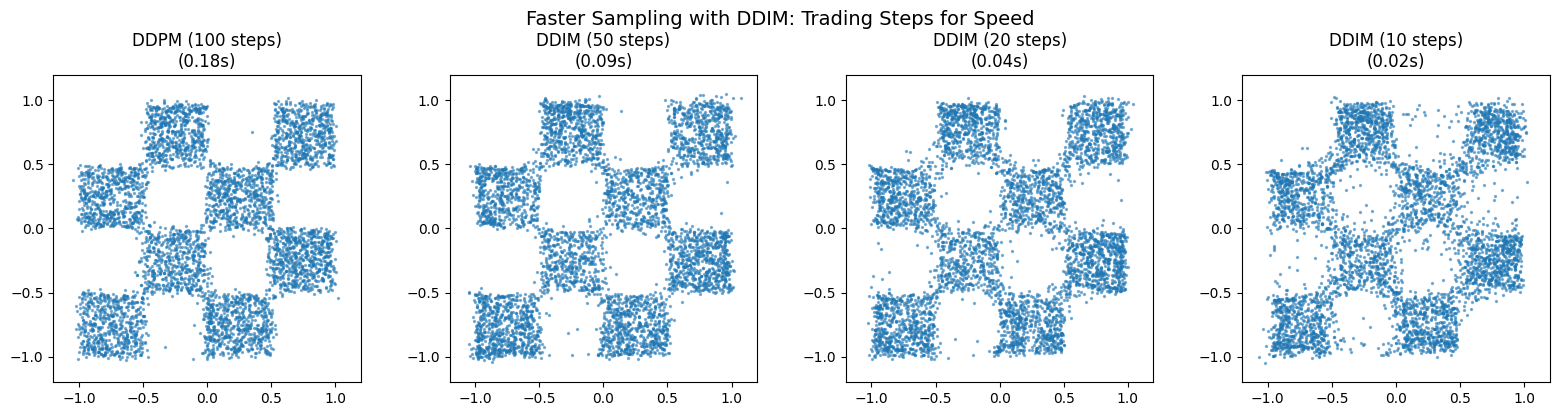

In [18]:
# 5. Faster Sampling with DDIM (Denoising Diffusion Implicit Models)
# DDIM allows us to skip steps during sampling, making generation faster
# The key insight: we can jump from t to t-k instead of t to t-1

@torch.no_grad()
def ddim_sample(model, n_samples, n_steps, alpha_bar, num_inference_steps=20, eta=0.0):
    """
    DDIM sampling with configurable number of inference steps.
    
    Args:
        model: Trained diffusion model
        n_samples: Number of samples to generate
        n_steps: Original number of training timesteps (e.g., 100)
        alpha_bar: Cumulative alpha values
        num_inference_steps: How many steps to use (fewer = faster)
        eta: Stochasticity parameter (0 = deterministic, 1 = DDPM-like)
    """
    model.eval()
    
    # Create a subset of timesteps to use
    step_ratio = n_steps // num_inference_steps
    timesteps = list(range(0, n_steps, step_ratio))[::-1]  # Reversed, from high to low
    
    # Start from noise
    x = torch.randn(n_samples, 2, device=device)
    
    for i, t in enumerate(timesteps):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        t_norm = (t_batch.float() / (n_steps - 1)).unsqueeze(1)
        
        # Predict noise
        eps_pred = model(x, t_norm)
        
        # Get alpha values
        a_bar_t = alpha_bar[t]
        
        # Predict x0 from xt and predicted noise
        x0_pred = (x - torch.sqrt(1 - a_bar_t) * eps_pred) / torch.sqrt(a_bar_t)
        
        # Get previous timestep
        if i < len(timesteps) - 1:
            t_prev = timesteps[i + 1]
            a_bar_t_prev = alpha_bar[t_prev]
        else:
            t_prev = 0
            a_bar_t_prev = torch.tensor(1.0, device=device)
        
        # DDIM formula
        sigma = eta * torch.sqrt((1 - a_bar_t_prev) / (1 - a_bar_t)) * torch.sqrt(1 - a_bar_t / a_bar_t_prev)
        
        # Direction pointing to xt
        dir_xt = torch.sqrt(1 - a_bar_t_prev - sigma**2) * eps_pred
        
        # Compute x_{t-1}
        if i < len(timesteps) - 1:
            noise = torch.randn_like(x) if eta > 0 else 0
            x = torch.sqrt(a_bar_t_prev) * x0_pred + dir_xt + sigma * noise
        else:
            x = x0_pred
    
    return x.cpu()

# Compare sampling speeds and quality
import time

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

configs = [
    ("DDPM (100 steps)", lambda: p_sample_loop(model, 5000, n_steps, beta, alpha, alpha_bar)),
    ("DDIM (50 steps)", lambda: ddim_sample(model, 5000, n_steps, alpha_bar, num_inference_steps=50)),
    ("DDIM (20 steps)", lambda: ddim_sample(model, 5000, n_steps, alpha_bar, num_inference_steps=20)),
    ("DDIM (10 steps)", lambda: ddim_sample(model, 5000, n_steps, alpha_bar, num_inference_steps=10)),
]

for i, (name, sampler) in enumerate(configs):
    start = time.time()
    samples = sampler()
    elapsed = time.time() - start
    
    pts = samples.numpy()
    axes[i].scatter(pts[:,0], pts[:,1], s=2, alpha=0.5)
    axes[i].set_xlim([-1.2, 1.2])
    axes[i].set_ylim([-1.2, 1.2])
    axes[i].set_aspect('equal')
    axes[i].set_title(f"{name}\n({elapsed:.2f}s)")

plt.suptitle("Faster Sampling with DDIM: Trading Steps for Speed", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Guided Generation (Classifier-Free Guidance Preview)

In practice, diffusion models often use **guidance** to steer generation toward desired properties. While our simple checkerboard model isn't conditional, we can demonstrate the concept by guiding samples toward a specific region.

The idea: during sampling, we can modify the predicted noise to push samples in a desired direction. This is a simplified version of what happens in text-to-image models like Stable Diffusion.

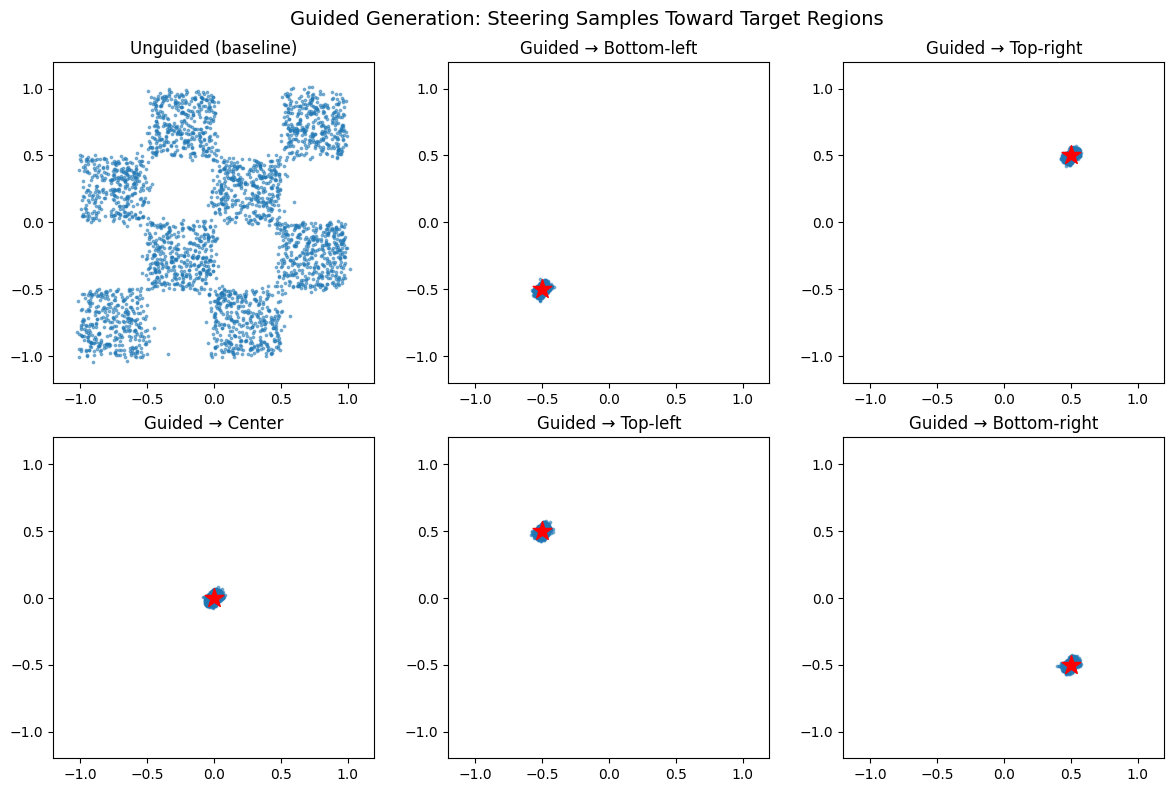

In [19]:
# 6. Simple Guided Generation
# Guide samples toward a target region using gradient-based guidance

@torch.no_grad()
def guided_sample(model, n_samples, n_steps, beta, alpha, alpha_bar, 
                  target_point, guidance_scale=1.0):
    """
    Generate samples guided toward a target point.
    This is a simplified demonstration of guidance principles.
    """
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    target = torch.tensor(target_point, device=device).unsqueeze(0)
    
    for t in reversed(range(n_steps)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        t_norm = (t_batch.float() / (n_steps - 1)).unsqueeze(1)
        
        eps_pred = model(x, t_norm)
        
        a_t = alpha[t]
        b_t = beta[t]
        a_bar_t = alpha_bar[t]
        
        # Standard DDPM mean
        mean = (1.0 / torch.sqrt(a_t)) * (x - (b_t / torch.sqrt(1.0 - a_bar_t)) * eps_pred)
        
        # Add guidance: nudge toward target
        # Scale guidance by how much signal remains (more guidance when less noisy)
        guidance_strength = guidance_scale * (1 - t / n_steps)
        direction_to_target = target - mean
        mean = mean + guidance_strength * direction_to_target * 0.1
        
        if t > 0:
            x = mean + torch.sqrt(b_t) * torch.randn_like(x)
        else:
            x = mean
    
    return x.cpu()

# Generate samples guided toward different corners
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Show unguided samples
unguided = p_sample_loop(model, 3000, n_steps, beta, alpha, alpha_bar)
pts = unguided.numpy()
axes[0, 0].scatter(pts[:,0], pts[:,1], s=3, alpha=0.5)
axes[0, 0].set_xlim([-1.2, 1.2])
axes[0, 0].set_ylim([-1.2, 1.2])
axes[0, 0].set_aspect('equal')
axes[0, 0].set_title("Unguided (baseline)")

# Guide toward different targets
targets = [
    ((-0.5, -0.5), "Bottom-left"),
    ((0.5, 0.5), "Top-right"),
    ((0.0, 0.0), "Center"),
    ((-0.5, 0.5), "Top-left"),
    ((0.5, -0.5), "Bottom-right"),
]

for i, (target, name) in enumerate(targets):
    row, col = (i // 3) + (1 if i >= 2 else 0), (i % 3) + (1 if i < 2 else 0)
    if i >= 2:
        row, col = 1, i - 2
    else:
        row, col = 0, i + 1
    
    guided = guided_sample(model, 3000, n_steps, beta, alpha, alpha_bar, 
                          target_point=target, guidance_scale=3.0)
    pts = guided.numpy()
    axes[row, col].scatter(pts[:,0], pts[:,1], s=3, alpha=0.5)
    axes[row, col].scatter([target[0]], [target[1]], s=200, c='red', marker='*', zorder=10)
    axes[row, col].set_xlim([-1.2, 1.2])
    axes[row, col].set_ylim([-1.2, 1.2])
    axes[row, col].set_aspect('equal')
    axes[row, col].set_title(f"Guided → {name}")

plt.suptitle("Guided Generation: Steering Samples Toward Target Regions", fontsize=14)
plt.tight_layout()
plt.show()

## Summary: Generation Techniques

| Technique | Use Case | Key Idea |
|-----------|----------|----------|
| **Basic Sampling** | Generate new samples | Start from noise, iteratively denoise |
| **Seeded Generation** | Reproducibility | Fix random seed for identical outputs |
| **Partial Denoising** | Image editing, inpainting | Start from corrupted data, not pure noise |
| **Noise Interpolation** | Smooth transitions | Interpolate in latent space, decode each point |
| **DDIM** | Faster generation | Skip timesteps, trade quality for speed |
| **Guided Sampling** | Conditional generation | Modify noise predictions to steer output |

These techniques form the foundation of modern diffusion-based generative AI:
- **Stable Diffusion** uses all of these + text conditioning
- **DALL-E 3** uses classifier-free guidance for text-to-image
- **Video diffusion** extends these ideas to temporal sequences

The same principles apply whether you're generating 2D checkerboard points or high-resolution images!

## Where Are Diffusion Models Used? Real-World Applications

Diffusion models have become the **dominant architecture** for generative AI across multiple domains. Here's where they're making the biggest impact:

### 🎨 Image Generation & Art

| Application | Examples | What It Does |
|-------------|----------|--------------|
| **Text-to-Image** | Stable Diffusion, DALL-E 3, Midjourney, Imagen | Generate images from text descriptions |
| **Image Editing** | Adobe Firefly, Photoshop Generative Fill | Inpainting, outpainting, style transfer |
| **Art & Design** | Runway, Leonardo.ai | Creative tools for artists and designers |
| **Stock Photography** | Shutterstock AI, Getty Images | Generate royalty-free images |

**Why diffusion dominates here:** The iterative refinement process produces high-quality, diverse outputs with fine-grained details that GANs struggle with.

### 🎬 Video Generation

| Application | Examples | What It Does |
|-------------|----------|--------------|
| **Text-to-Video** | Sora (OpenAI), Runway Gen-3, Pika | Generate videos from text prompts |
| **Video Editing** | Frame interpolation, video inpainting | Smooth transitions, remove objects |
| **Animation** | Character animation, motion synthesis | Generate realistic movement |

**Key insight:** Video diffusion extends image diffusion by treating time as another dimension to denoise.

### 🔊 Audio & Music

| Application | Examples | What It Does |
|-------------|----------|--------------|
| **Music Generation** | Riffusion, MusicLM, Stable Audio | Create songs, instrumentals, sound effects |
| **Speech Synthesis** | Bark, Tortoise TTS | Natural-sounding text-to-speech |
| **Audio Restoration** | Noise removal, upsampling | Enhance audio quality |

### 🧬 Scientific Applications

| Field | Application | Impact |
|-------|-------------|--------|
| **Drug Discovery** | Molecule generation (DiffDock, RFdiffusion) | Design new drug candidates |
| **Protein Design** | AlphaFold + diffusion | Generate novel protein structures |
| **Materials Science** | Crystal structure prediction | Discover new materials |
| **Medical Imaging** | MRI/CT image enhancement | Better diagnostics |

### 🏭 Industry Adoption

**Tech Giants Using Diffusion:**
- **Google:** Imagen, MusicLM, video generation research
- **OpenAI:** DALL-E 3, Sora
- **Meta:** Make-A-Video, AudioCraft
- **Adobe:** Firefly (integrated into Creative Cloud)
- **Microsoft:** Copilot image features (via DALL-E)
- **Stability AI:** Stable Diffusion ecosystem

**Startups & Scale:**
- Midjourney: 16M+ users, $200M+ annual revenue
- Runway: Used in Oscar-winning films ("Everything Everywhere All at Once")
- Hugging Face: Hosts 100K+ diffusion model variants

## What Can You Build with Diffusion Models?

Here's a practical overview of what diffusion models enable you to create:

### 1. **Unconditional Generation**
Generate new samples from the learned distribution (what we did in this notebook).

```
Pure Noise → Iterative Denoising → New Data Sample
```

**Use cases:** Data augmentation, synthetic data generation, artistic exploration

### 2. **Conditional Generation**
Guide the generation process with additional information.

| Condition Type | Example | Application |
|----------------|---------|-------------|
| Text prompts | "A cat wearing a hat" | DALL-E, Stable Diffusion |
| Class labels | "Generate a dog" | ImageNet generation |
| Reference images | Style transfer | Artistic filters |
| Sketches/edges | Sketch-to-image | Design tools |
| Semantic maps | Layout-to-image | Architecture visualization |

### 3. **Image-to-Image Translation**
Transform one image into another while preserving structure.

```
Input Image → Add Noise → Denoise with New Condition → Transformed Image
```

**Examples:**
- Day → Night conversion
- Sketch → Photorealistic image
- Low-res → High-res (super-resolution)
- Damaged photo → Restored photo

### 4. **Inpainting & Outpainting**
Fill in missing regions or extend images beyond their boundaries.

```
Image with Mask → Denoise only masked region → Seamlessly filled image
```

**Use cases:**
- Remove unwanted objects from photos
- Extend image canvas (outpainting)
- Restore old/damaged photographs

### 5. **Interpolation & Morphing**
Create smooth transitions between two images or concepts.

```
Image A → Encode to noise → Interpolate → Decode → Image B
```

### 6. **Controllable Editing**
Make targeted edits while preserving the rest of the image.

**Techniques:**
- **Prompt-to-prompt:** Change "a cat" to "a dog" in an image
- **Attention editing:** Modify specific regions
- **ControlNet:** Add precise structural control (poses, edges, depth)

### 7. **3D and Beyond**
Emerging applications extending diffusion to new domains:

| Domain | What It Generates |
|--------|-------------------|
| 3D Objects | Point clouds, meshes, NeRFs |
| Motion | Human poses, animations |
| Molecules | Drug candidates, proteins |
| Layouts | UI designs, floor plans |
| Code | (Research area) |

## Why Diffusion Models Won (Over GANs and VAEs)

Understanding why diffusion became dominant helps appreciate the field's trajectory:

| Aspect | GANs | VAEs | Diffusion |
|--------|------|------|-----------|
| **Training Stability** | Fragile (mode collapse) | Stable | Very stable |
| **Sample Quality** | High (but inconsistent) | Blurry | Highest |
| **Diversity** | Limited (mode collapse) | Good | Excellent |
| **Likelihood** | No | Yes | Yes |
| **Controllability** | Difficult | Moderate | Excellent |
| **Scalability** | Difficult | Good | Excellent |

**Key advantages of diffusion:**
1. **Stable training:** No adversarial dynamics, just MSE loss
2. **Mode coverage:** Doesn't collapse to a few outputs
3. **Compositionality:** Easily add conditions and controls
4. **Theoretical foundation:** Grounded in thermodynamics and score matching

## Looking Forward: The Future of Diffusion

### Current Research Frontiers

1. **Speed improvements:**
   - Consistency models (1-step generation)
   - Distillation techniques
   - Better ODE solvers

2. **Quality improvements:**
   - Higher resolution (4K+)
   - Better temporal consistency (video)
   - Improved text understanding

3. **New modalities:**
   - Unified models (text + image + audio + video)
   - 3D generation becoming practical
   - Robotics and embodied AI

4. **Efficiency:**
   - Smaller models with same quality
   - On-device generation
   - Real-time applications

### What's Next?

The techniques you learned in this notebook are the **exact same principles** used in state-of-the-art models:

```
This notebook                    Stable Diffusion / DALL-E 3
─────────────────────────────────────────────────────────────
2D points                   →    Latent image representations
Simple MLP                  →    U-Net with attention
100 timesteps              →    1000 timesteps
Unconditional              →    Text-conditioned (CLIP)
MSE noise loss             →    MSE noise loss (same!)
DDPM/DDIM sampling         →    DDPM/DDIM sampling (same!)
```

The core algorithm is identical. The differences are scale, conditioning, and architecture details.

**Congratulations!** You now understand the fundamental mechanics of the most powerful generative AI technology available today.